# Smart Learning System

# Notebook 01 – Data Understanding and Exploratory Data Analysis (EDA)

## Overview

This notebook performs the initial exploration and understanding of the datasets used in the Smart Learning System. The primary objective is to evaluate the quality, structure, completeness, and characteristics of each dataset before preprocessing and machine learning model development.

The Smart Learning System is designed to support **Sri Lankan GCE Advanced Level Commerce students** by providing academic risk prediction, pass/fail prediction, learning analytics, and intelligent educational support.

---

## Objectives

The objectives of this notebook are to:

- Understand the structure of each dataset.
- Identify numerical and categorical variables.
- Detect missing values and duplicate records.
- Analyse data types and descriptive statistics.
- Examine class distributions.
- Identify potential data quality issues.
- Analyse correlations among numerical variables.
- Produce visualisations to better understand the datasets.
- Prepare the datasets for preprocessing and machine learning.

---

## Datasets Used

### 1. Pass/Fail Dataset (`pass_fail_dataset.csv`)

This dataset is used to develop the binary classification model for predicting whether a student is likely to pass or fail.

Main variables include:

- Student ID
- Attendance Percentage
- Homework Completion Percentage
- Mid-Term Performance
- Weekly Study Hours
- Pass/Fail Outcome

---

### 2. Academic Mark Sheet Dataset (`mark_sheet_clean_file1.csv`)

This dataset contains students' academic marks and attendance records.

Although the original dataset contains generic subject-score variables, it will be transformed during preprocessing into a **Commerce-domain prototype dataset** by mapping the numerical scores to:

- Accounting
- Business Studies
- Economics

The transformed dataset will later be used to develop the multi-class academic risk prediction model.

---

### 3. xAPI Educational Dataset (`xAPI-Edu-Data.csv`)

The xAPI Educational Dataset is a publicly available educational dataset used as an external benchmark.

It contains demographic information, classroom engagement indicators, learning activities, and academic performance classes.

This dataset will be used only for benchmarking and comparison because it does not directly represent Sri Lankan GCE Advanced Level Commerce students.

---

## Expected Outputs

At the end of this notebook, the following information will be available:

- Dataset dimensions
- Feature descriptions
- Missing-value analysis
- Duplicate-record analysis
- Descriptive statistics
- Target-class distributions
- Correlation analysis
- Data quality summary
- Exploratory visualisations

The processed findings from this notebook will be used in **Notebook 02 – Data Preprocessing**.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Resolve project paths
# ---------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

# Works when notebook is opened from ml-model/notebooks
if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
else:
    ML_ROOT = NOTEBOOK_DIR / "ml-model"

RAW_DATA_DIR = ML_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("ML root:", ML_ROOT.resolve())
print("Raw data directory:", RAW_DATA_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Raw data directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/raw
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


In [2]:
dataset_files = sorted(RAW_DATA_DIR.glob("*.csv"))

if not dataset_files:
    raise FileNotFoundError(
        f"No CSV datasets were found in: {RAW_DATA_DIR.resolve()}"
    )

print("Available datasets:")

for file_path in dataset_files:
    print(f"- {file_path.name}")

Available datasets:
- mark_sheet_clean_file1.csv
- pass_fail_dataset.csv
- xAPI-Edu-Data.csv


In [3]:
def load_csv_dataset(file_name: str) -> pd.DataFrame:
    file_path = RAW_DATA_DIR / file_name

    if not file_path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {file_path.resolve()}"
        )

    dataframe = pd.read_csv(file_path)

    print(
        f"Loaded {file_name}: "
        f"{dataframe.shape[0]:,} rows × "
        f"{dataframe.shape[1]} columns"
    )

    return dataframe


pass_fail_df = load_csv_dataset("pass_fail_dataset.csv")
mark_sheet_df = load_csv_dataset("mark_sheet_clean_file1.csv")
xapi_df = load_csv_dataset("xAPI-Edu-Data.csv")

Loaded pass_fail_dataset.csv: 1,500 rows × 6 columns
Loaded mark_sheet_clean_file1.csv: 1,005 rows × 4 columns
Loaded xAPI-Edu-Data.csv: 480 rows × 17 columns


In [4]:
print("PASS/FAIL DATASET")
display(pass_fail_df.head())

print("\nMARK SHEET DATASET")
display(mark_sheet_df.head())

print("\nXAPI DATASET")
display(xapi_df.head())

PASS/FAIL DATASET


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,59.7,66.5,73.4,6.4,1
1,2,74.3,54.7,18.3,1.2,0
2,3,81.8,98.9,70.7,11.1,1
3,4,89.4,85.3,74.2,5.6,1
4,5,60.5,21.9,37.3,7.5,0



MARK SHEET DATASET


,Math_Score,English_Score,Science_Score,Attendance
0,79.967142,86.792265,72.598574,75.460962
1,73.617357,81.095604,76.843851,80.698075
2,81.476885,70.715564,71.660641,82.931972
3,90.230299,62.236759,75.536308,94.438438
4,72.658466,78.378680,62.851083,87.782766



XAPI DATASET


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [5]:
def dataset_overview(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    overview = pd.DataFrame({
        "column": dataframe.columns,
        "data_type": dataframe.dtypes.astype(str).values,
        "non_null_count": dataframe.notna().sum().values,
        "missing_count": dataframe.isna().sum().values,
        "missing_percentage": (
            dataframe.isna().mean().values * 100
        ).round(2),
        "unique_values": dataframe.nunique(dropna=False).values,
    })

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)
    print(f"Rows: {dataframe.shape[0]:,}")
    print(f"Columns: {dataframe.shape[1]}")
    print(f"Duplicate rows: {dataframe.duplicated().sum():,}")

    return overview

In [6]:
pass_fail_overview = dataset_overview(
    pass_fail_df,
    "Pass/Fail Dataset",
)

display(pass_fail_overview)

Pass/Fail Dataset
Rows: 1,500
Columns: 6
Duplicate rows: 0


,column,data_type,non_null_count,missing_count,missing_percentage,unique_values
0,student_id,int64,1500,0,0.0,1500
1,attendance_pct,float64,1500,0,0.0,481
2,homework_pct,float64,1500,0,0.0,557
3,midterm_score,float64,1500,0,0.0,621
4,study_hours_per_week,float64,1500,0,0.0,167
5,pass,int64,1500,0,0.0,2


In [7]:
mark_sheet_overview = dataset_overview(
    mark_sheet_df,
    "Mark Sheet Dataset",
)

display(mark_sheet_overview)

Mark Sheet Dataset
Rows: 1,005
Columns: 4
Duplicate rows: 3


,column,data_type,non_null_count,missing_count,missing_percentage,unique_values
0,Math_Score,float64,1005,0,0.0,999
1,English_Score,float64,1005,0,0.0,1000
2,Science_Score,float64,1005,0,0.0,1000
3,Attendance,float64,1005,0,0.0,1002


In [8]:
xapi_overview = dataset_overview(
    xapi_df,
    "xAPI-Edu-Data",
)

display(xapi_overview)

xAPI-Edu-Data
Rows: 480
Columns: 17
Duplicate rows: 2


,column,data_type,non_null_count,missing_count,missing_percentage,unique_values
0,gender,str,480,0,0.0,2
1,NationalITy,str,480,0,0.0,14
2,PlaceofBirth,str,480,0,0.0,14
3,StageID,str,480,0,0.0,3
4,GradeID,str,480,0,0.0,10
5,SectionID,str,480,0,0.0,3
6,Topic,str,480,0,0.0,12
7,Semester,str,480,0,0.0,2
8,Relation,str,480,0,0.0,2
9,raisedhands,int64,480,0,0.0,82


In [9]:
def show_descriptive_statistics(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> None:
    print("=" * 70)
    print(f"{dataset_name} — Numerical Statistics")
    print("=" * 70)

    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns

    if len(numerical_columns) == 0:
        print("No numerical columns found.")
    else:
        display(
            dataframe[numerical_columns]
            .describe()
            .T
            .round(2)
        )

    print("=" * 70)
    print(f"{dataset_name} — Categorical Statistics")
    print("=" * 70)

    categorical_columns = dataframe.select_dtypes(
        exclude=np.number
    ).columns

    if len(categorical_columns) == 0:
        print("No categorical columns found.")
    else:
        display(
            dataframe[categorical_columns]
            .describe()
            .T
        )

In [10]:
show_descriptive_statistics(
    pass_fail_df,
    "Pass/Fail Dataset",
)

show_descriptive_statistics(
    mark_sheet_df,
    "Mark Sheet Dataset",
)

show_descriptive_statistics(
    xapi_df,
    "xAPI-Edu-Data",
)

Pass/Fail Dataset — Numerical Statistics


,count,mean,std,min,25%,50%,75%,max
student_id,1500.0,750.50,433.16,1.0,375.75,750.50,1125.25,1500.0
attendance_pct,1500.0,75.52,13.21,35.0,66.47,75.45,85.00,100.0
homework_pct,1500.0,68.32,16.94,20.0,56.98,68.40,81.05,100.0
midterm_score,1500.0,60.37,17.96,10.0,48.08,60.10,72.90,100.0
study_hours_per_week,1500.0,6.85,3.73,0.0,4.10,6.80,9.40,19.9
pass,1500.0,0.59,0.49,0.0,0.00,1.00,1.00,1.0


Pass/Fail Dataset — Categorical Statistics
No categorical columns found.
Mark Sheet Dataset — Numerical Statistics


,count,mean,std,min,25%,50%,75%,max
Math_Score,1005.0,75.20,9.83,45.06,68.53,75.26,81.48,105.38
English_Score,1005.0,70.87,12.06,34.33,62.73,70.76,78.82,107.42
Science_Score,1005.0,78.02,7.90,53.61,72.80,77.95,83.27,102.43
Attendance,1005.0,84.89,5.18,68.82,81.24,84.98,88.33,100.90


Mark Sheet Dataset — Categorical Statistics
No categorical columns found.
xAPI-Edu-Data — Numerical Statistics


,count,mean,std,min,25%,50%,75%,max
raisedhands,480.0,46.78,30.78,0.0,15.75,50.0,75.0,100.0
VisITedResources,480.0,54.80,33.08,0.0,20.00,65.0,84.0,99.0
AnnouncementsView,480.0,37.92,26.61,0.0,14.00,33.0,58.0,98.0
Discussion,480.0,43.28,27.64,1.0,20.00,39.0,70.0,99.0


xAPI-Edu-Data — Categorical Statistics


,count,unique,top,freq
gender,480,2,M,305
NationalITy,480,14,KW,179
PlaceofBirth,480,14,KuwaIT,180
StageID,480,3,MiddleSchool,248
GradeID,480,10,G-02,147
SectionID,480,3,A,283
Topic,480,12,IT,95
Semester,480,2,F,245
Relation,480,2,Father,283
ParentAnsweringSurvey,480,2,Yes,270


In [11]:
def missing_value_summary(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    summary = pd.DataFrame({
        "column": dataframe.columns,
        "missing_count": dataframe.isna().sum().values,
        "missing_percentage": (
            dataframe.isna().mean().values * 100
        ).round(2),
    })

    summary = summary[
        summary["missing_count"] > 0
    ].sort_values(
        "missing_percentage",
        ascending=False,
    )

    print(f"{dataset_name}: {len(summary)} columns contain missing values.")

    return summary

In [12]:
display(
    missing_value_summary(
        pass_fail_df,
        "Pass/Fail Dataset",
    )
)

display(
    missing_value_summary(
        mark_sheet_df,
        "Mark Sheet Dataset",
    )
)

display(
    missing_value_summary(
        xapi_df,
        "xAPI-Edu-Data",
    )
)

Pass/Fail Dataset: 0 columns contain missing values.


,column,missing_count,missing_percentage


Mark Sheet Dataset: 0 columns contain missing values.


,column,missing_count,missing_percentage


xAPI-Edu-Data: 0 columns contain missing values.


,column,missing_count,missing_percentage


In [13]:
duplicate_summary = pd.DataFrame({
    "dataset": [
        "Pass/Fail",
        "Mark Sheet",
        "xAPI",
    ],
    "total_rows": [
        len(pass_fail_df),
        len(mark_sheet_df),
        len(xapi_df),
    ],
    "duplicate_rows": [
        pass_fail_df.duplicated().sum(),
        mark_sheet_df.duplicated().sum(),
        xapi_df.duplicated().sum(),
    ],
})

duplicate_summary["duplicate_percentage"] = (
    duplicate_summary["duplicate_rows"]
    / duplicate_summary["total_rows"]
    * 100
).round(2)

display(duplicate_summary)

,dataset,total_rows,duplicate_rows,duplicate_percentage
0,Pass/Fail,1500,0,0.00
1,Mark Sheet,1005,3,0.30
2,xAPI,480,2,0.42


In [14]:
def print_columns(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> None:
    print(f"\n{dataset_name}")

    for index, column in enumerate(
        dataframe.columns,
        start=1,
    ):
        print(f"{index:02d}. {column}")


print_columns(pass_fail_df, "Pass/Fail Dataset Columns")
print_columns(mark_sheet_df, "Mark Sheet Dataset Columns")
print_columns(xapi_df, "xAPI Dataset Columns")


Pass/Fail Dataset Columns
01. student_id
02. attendance_pct
03. homework_pct
04. midterm_score
05. study_hours_per_week
06. pass

Mark Sheet Dataset Columns
01. Math_Score
02. English_Score
03. Science_Score
04. Attendance

xAPI Dataset Columns
01. gender
02. NationalITy
03. PlaceofBirth
04. StageID
05. GradeID
06. SectionID
07. Topic
08. Semester
09. Relation
10. raisedhands
11. VisITedResources
12. AnnouncementsView
13. Discussion
14. ParentAnsweringSurvey
15. ParentschoolSatisfaction
16. StudentAbsenceDays
17. Class


In [15]:
candidate_target_names = [
    "pass",
    "pass_fail",
    "result",
    "target",
    "risk",
    "risk_level",
    "class",
    "Class",
    "status",
    "performance",
]


def find_candidate_targets(
    dataframe: pd.DataFrame,
) -> list[str]:
    candidates = []

    for column in dataframe.columns:
        normalized_name = column.strip().lower()

        if any(
            candidate.lower() == normalized_name
            for candidate in candidate_target_names
        ):
            candidates.append(column)

    return candidates


print(
    "Pass/Fail candidate targets:",
    find_candidate_targets(pass_fail_df),
)

print(
    "Mark Sheet candidate targets:",
    find_candidate_targets(mark_sheet_df),
)

print(
    "xAPI candidate targets:",
    find_candidate_targets(xapi_df),
)

Pass/Fail candidate targets: ['pass']
Mark Sheet candidate targets: []
xAPI candidate targets: ['Class']


In [16]:
def inspect_low_cardinality_columns(
    dataframe: pd.DataFrame,
    dataset_name: str,
    maximum_unique_values: int = 10,
) -> None:
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    for column in dataframe.columns:
        unique_count = dataframe[column].nunique(
            dropna=False
        )

        if unique_count <= maximum_unique_values:
            print(f"\nColumn: {column}")
            print(
                dataframe[column]
                .value_counts(dropna=False)
                .to_string()
            )


inspect_low_cardinality_columns(
    pass_fail_df,
    "Pass/Fail Low-Cardinality Columns",
)

inspect_low_cardinality_columns(
    mark_sheet_df,
    "Mark Sheet Low-Cardinality Columns",
)

inspect_low_cardinality_columns(
    xapi_df,
    "xAPI Low-Cardinality Columns",
)

Pass/Fail Low-Cardinality Columns

Column: pass
pass
1    883
0    617
Mark Sheet Low-Cardinality Columns
xAPI Low-Cardinality Columns

Column: gender
gender
M    305
F    175

Column: StageID
StageID
MiddleSchool    248
lowerlevel      199
HighSchool       33

Column: GradeID
GradeID
G-02    147
G-08    116
G-07    101
G-04     48
G-06     32
G-11     13
G-12     11
G-09      5
G-10      4
G-05      3

Column: SectionID
SectionID
A    283
B    167
C     30

Column: Semester
Semester
F    245
S    235

Column: Relation
Relation
Father    283
Mum       197

Column: ParentAnsweringSurvey
ParentAnsweringSurvey
Yes    270
No     210

Column: ParentschoolSatisfaction
ParentschoolSatisfaction
Good    292
Bad     188

Column: StudentAbsenceDays
StudentAbsenceDays
Under-7    289
Above-7    191

Column: Class
Class
M    211
H    142
L    127


In [17]:
import matplotlib.pyplot as plt

def plot_target_distribution(
    dataframe,
    target_column,
    title,
    file_name,
):
    if target_column not in dataframe.columns:
        print(f"Target column '{target_column}' was not found.")
        return

    counts = dataframe[target_column].value_counts()

    percentages = (
        counts / counts.sum() * 100
    ).round(2)

    display(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages,
        })
    )

    plt.figure(figsize=(8,5))

    counts.plot(
        kind="bar",
        edgecolor="black"
    )

    plt.title(title)
    plt.xlabel(target_column)
    plt.ylabel("Number of Records")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / file_name,
        dpi=300
    )

    plt.show()

In [18]:
# Change these values only if the actual dataset columns are different.

PASS_FAIL_TARGET = "pass"
MARK_SHEET_TARGET = "None"
XAPI_TARGET = "Class"

print("Pass/Fail target:", PASS_FAIL_TARGET)
print("Mark Sheet target:", MARK_SHEET_TARGET)
print("xAPI target:", XAPI_TARGET)

Pass/Fail target: pass
Mark Sheet target: None
xAPI target: Class


,count,percentage
pass,,
1,883,58.87
0,617,41.13


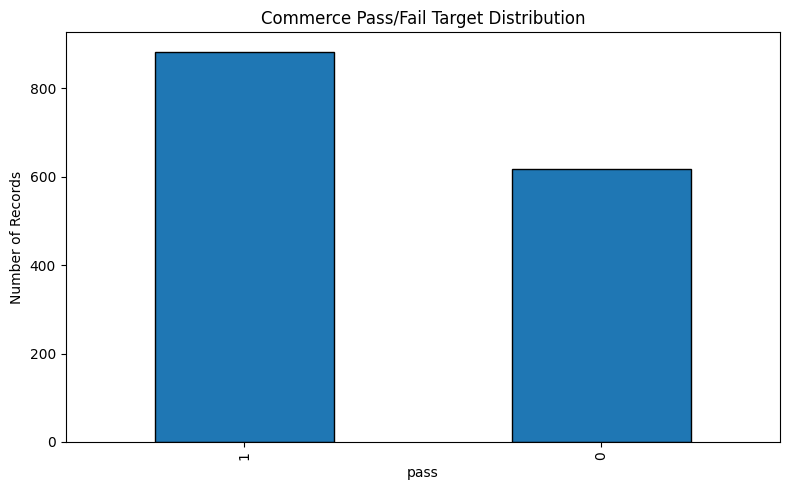

Target column 'None' was not found.


,count,percentage
Class,,
M,211,43.96
H,142,29.58
L,127,26.46


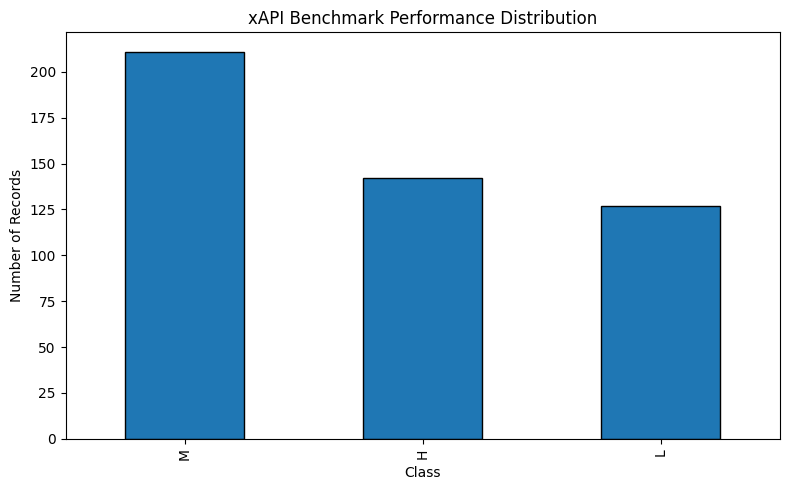

In [19]:
plot_target_distribution(
    pass_fail_df,
    PASS_FAIL_TARGET,
    "Commerce Pass/Fail Target Distribution",
    "commerce_pass_fail_target_distribution.png",
)

if MARK_SHEET_TARGET is not None:
    plot_target_distribution(
        mark_sheet_df,
        MARK_SHEET_TARGET,
        "Commerce Risk Distribution",
        "commerce_risk_distribution.png",
    )
else:
    print(
        "The raw mark-sheet dataset has no target column. "
        "Commerce risk labels will be created in Notebook 02."
    )

plot_target_distribution(
    xapi_df,
    XAPI_TARGET,
    "xAPI Benchmark Performance Distribution",
    "xapi_target_distribution.png",
)

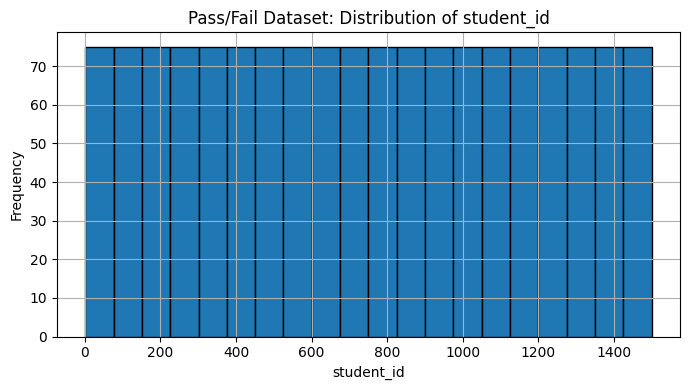

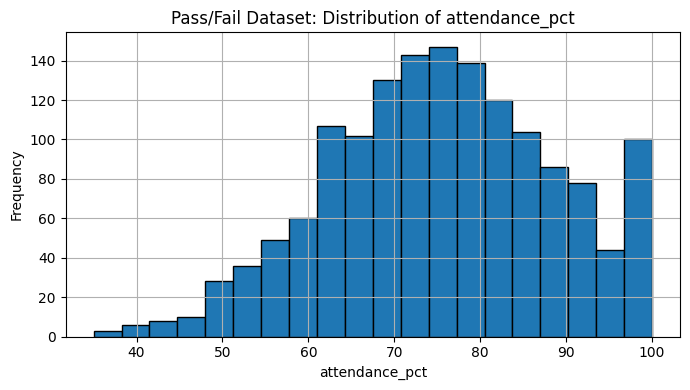

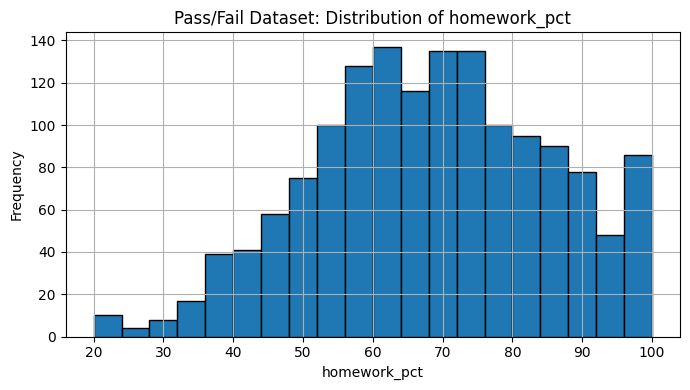

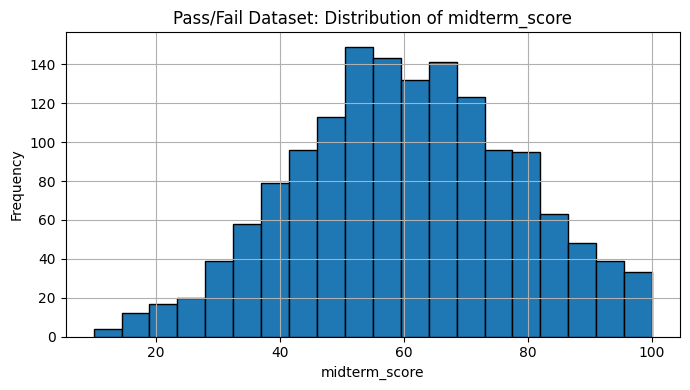

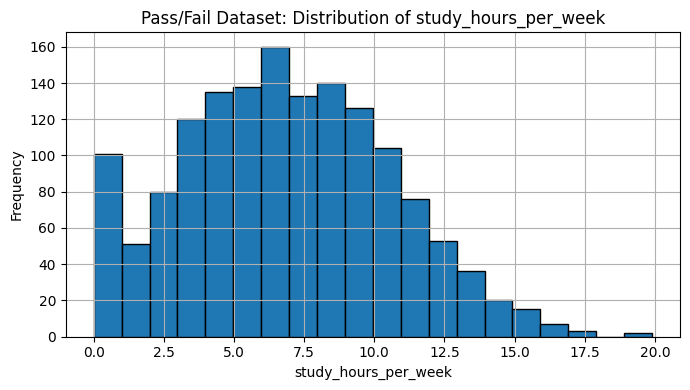

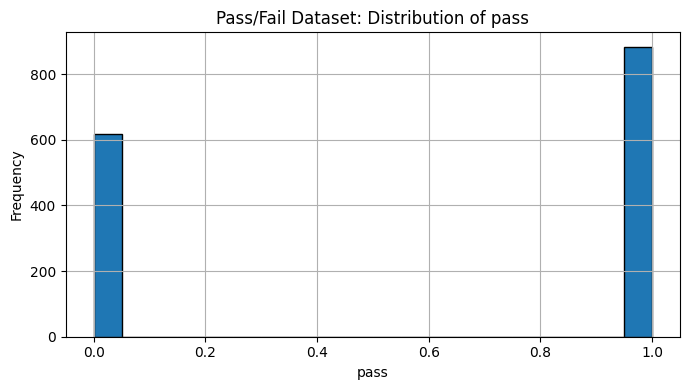

In [20]:
def plot_numerical_histograms(
    dataframe: pd.DataFrame,
    dataset_name: str,
    file_prefix: str,
) -> None:
    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns.tolist()

    if not numerical_columns:
        print(
            f"No numerical columns found in {dataset_name}."
        )
        return

    for column in numerical_columns:
        plt.figure(figsize=(7, 4))
        dataframe[column].dropna().hist(
            bins=20,
            edgecolor="black",
        )

        plt.title(
            f"{dataset_name}: Distribution of {column}"
        )
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.tight_layout()

        safe_column_name = (
            column.lower()
            .replace(" ", "_")
            .replace("/", "_")
        )

        output_path = (
            FIGURES_DIR
            / f"{file_prefix}_{safe_column_name}_distribution.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


plot_numerical_histograms(
    pass_fail_df,
    "Pass/Fail Dataset",
    "pass_fail",
)

In [21]:
def calculate_iqr_outliers(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns

    for column in numerical_columns:
        series = dataframe[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (series < lower_bound)
            | (series > upper_bound)
        ).sum()

        rows.append({
            "column": column,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "lower_bound": round(lower_bound, 2),
            "upper_bound": round(upper_bound, 2),
            "outlier_count": int(outlier_count),
            "outlier_percentage": round(
                outlier_count / len(series) * 100,
                2,
            ),
        })

    return pd.DataFrame(rows)


pass_fail_outliers = calculate_iqr_outliers(
    pass_fail_df
)

display(pass_fail_outliers)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,student_id,375.75,1125.25,749.50,-748.50,2249.50,0,0.00
1,attendance_pct,66.47,85.00,18.53,38.69,112.79,5,0.33
2,homework_pct,56.98,81.05,24.07,20.86,117.16,8,0.53
3,midterm_score,48.08,72.90,24.83,10.84,110.14,2,0.13
4,study_hours_per_week,4.10,9.40,5.30,-3.85,17.35,5,0.33
5,pass,0.00,1.00,1.00,-1.50,2.50,0,0.00


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
student_id,1.000,0.092,0.041,0.040,0.055,0.051
attendance_pct,0.092,1.000,0.621,0.408,0.540,0.397
homework_pct,0.041,0.621,1.000,0.429,0.521,0.426
midterm_score,0.040,0.408,0.429,1.000,0.354,0.458
study_hours_per_week,0.055,0.540,0.521,0.354,1.000,0.366
pass,0.051,0.397,0.426,0.458,0.366,1.000


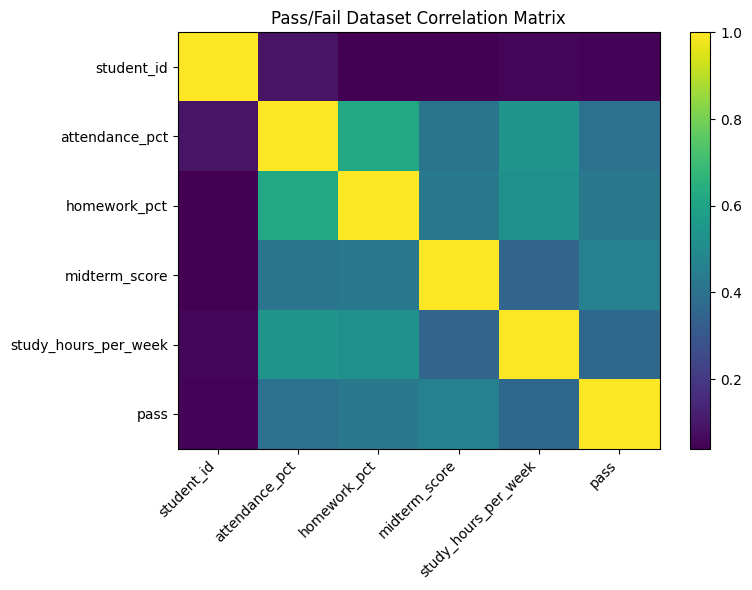

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/pass_fail_correlation_matrix.png


,Math_Score,English_Score,Science_Score,Attendance
Math_Score,1.000,-0.022,0.040,0.004
English_Score,-0.022,1.000,0.007,-0.039
Science_Score,0.040,0.007,1.000,0.039
Attendance,0.004,-0.039,0.039,1.000


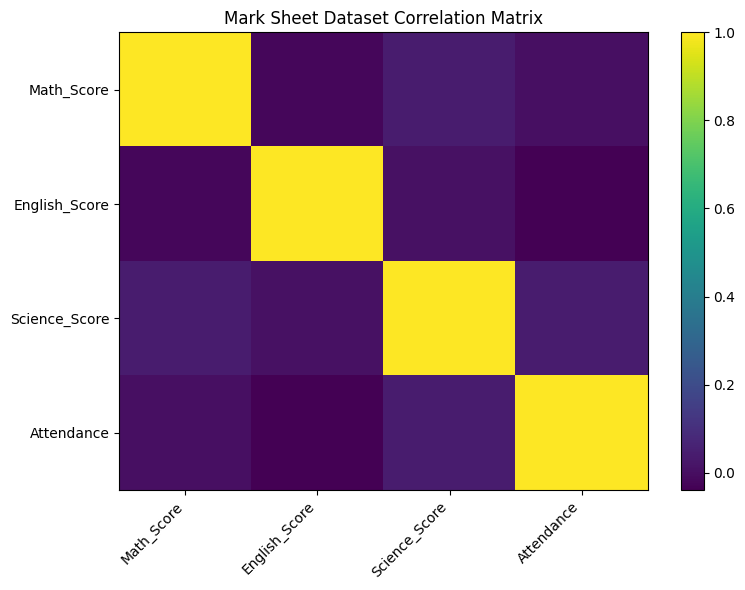

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/mark_sheet_correlation_matrix.png


In [22]:
def plot_correlation_matrix(
    dataframe: pd.DataFrame,
    dataset_name: str,
    file_name: str,
) -> None:
    numerical_dataframe = dataframe.select_dtypes(
        include=np.number
    )

    if numerical_dataframe.shape[1] < 2:
        print(
            f"Not enough numerical columns in {dataset_name}."
        )
        return

    correlation_matrix = (
        numerical_dataframe.corr()
    )

    display(correlation_matrix.round(3))

    plt.figure(
        figsize=(
            max(8, correlation_matrix.shape[1]),
            max(6, correlation_matrix.shape[1] * 0.8),
        )
    )

    image = plt.imshow(
        correlation_matrix,
        aspect="auto",
        interpolation="nearest",
    )

    plt.colorbar(image)
    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=45,
        ha="right",
    )
    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
    )

    plt.title(f"{dataset_name} Correlation Matrix")
    plt.tight_layout()

    output_path = FIGURES_DIR / file_name
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", output_path)


plot_correlation_matrix(
    pass_fail_df,
    "Pass/Fail Dataset",
    "pass_fail_correlation_matrix.png",
)

plot_correlation_matrix(
    mark_sheet_df,
    "Mark Sheet Dataset",
    "mark_sheet_correlation_matrix.png",
)

In [23]:
data_quality_report = pd.DataFrame({
    "dataset": [
        "Pass/Fail",
        "Mark Sheet",
        "xAPI",
    ],
    "rows": [
        pass_fail_df.shape[0],
        mark_sheet_df.shape[0],
        xapi_df.shape[0],
    ],
    "columns": [
        pass_fail_df.shape[1],
        mark_sheet_df.shape[1],
        xapi_df.shape[1],
    ],
    "missing_values": [
        int(pass_fail_df.isna().sum().sum()),
        int(mark_sheet_df.isna().sum().sum()),
        int(xapi_df.isna().sum().sum()),
    ],
    "duplicate_rows": [
        int(pass_fail_df.duplicated().sum()),
        int(mark_sheet_df.duplicated().sum()),
        int(xapi_df.duplicated().sum()),
    ],
})

report_path = (
    REPORTS_DIR
    / "data_quality_summary.csv"
)

data_quality_report.to_csv(
    report_path,
    index=False,
)

display(data_quality_report)

print("Saved:", report_path)

,dataset,rows,columns,missing_values,duplicate_rows
0,Pass/Fail,1500,6,0,0
1,Mark Sheet,1005,4,0,3
2,xAPI,480,17,0,2


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/data_quality_summary.csv


## Notebook Summary

Three datasets were explored.

### Pass/Fail Dataset

This dataset will be used to develop the primary binary classification model for student pass/fail prediction.

### Mark Sheet Dataset

This dataset serves as the raw academic mark-sheet dataset.

In Notebook 02, it will be transformed into a Commerce-specific dataset by renaming the numerical subject-score variables to:

- Accounting
- Business Studies
- Economics

A new target variable (`risk_level`) will be generated based on academic performance and attendance.

The processed Commerce dataset will then be used for training the multi-class academic-risk prediction model.

### xAPI Dataset

The xAPI dataset will be used only as an external benchmark model.

Its educational context differs from the Sri Lankan A/L Commerce curriculum, therefore it will not be considered the primary production model.

### Next Notebook

Notebook 02 will perform:

- Duplicate removal
- Data validation
- Commerce dataset transformation
- Risk label generation
- Processed dataset export